

# Project: Soccer Data Analysis

## Table of Contents
<ul>
<li><a href="#intro">Introduction</a></li>
<li><a href="#wrangling">Data Wrangling</a></li>
<li><a href="#eda">Exploratory Data Analysis</a></li>
<li><a href="#conclusions">Conclusions</a></li>
</ul>

<a id='intro'></a>
## Introduction
### at this project will investigate the date associated with the Soccer database and we interested to find the which teams that has imporved during the season from 2008/2009 to 2015/2016 also finding the facors that corrolated with players rating 

In [1]:
import pandas as pd 
import numpy as np
from datetime import datetime as dt
import sqlite3 
import matplotlib.pyplot as plt
%matplotlib inline

<a id='wrangling'></a>
## Data Wrangling

### General Properties

In [2]:
con = sqlite3.connect("database.sqlite")

# Load the data into a DataFrame
df_league = pd.read_sql_query("SELECT \
                              l.id,l.name as league,c.name as country \
                              from \
                              country c \
                              join league l\
                              on c.id=l.id", con)
df_match = pd.read_sql_query("SELECT id,league_id,season,home_team_api_id as home_id,away_team_api_id as away_id,home_team_goal,away_team_goal from match", con)
df_player = pd.read_sql_query("SELECT * from player", con)
df_player_att= pd.read_sql_query("SELECT player_api_id as id,overall_rating as rating, preferred_foot as foot,finishing,free_kick_accuracy as 'free_kick',sprint_speed as sprint,shot_power,jumping,penalties from player_attributes", con)
df_team = pd.read_sql_query("SELECT team_api_id as id , team_long_name as name from team", con)
con.close()

In [3]:
df={"match":df_match,
  "player":df_player,
  "player_att":df_player_att,
  "team":df_team,}

df = pd.Series(df)
df

match                   id  league_id     season  home_id  a...
player                  id  player_api_id          player_na...
player_att                id  rating   foot  finishing  free...
team                  id                name
0     9987     ...
dtype: object


### Data Cleaning (handling duplicates ,missing values and merging some dataframes then adding some colums)

#### first we will check for missing values

In [4]:
for i in df:
    print(i.isna().sum())

id                0
league_id         0
season            0
home_id           0
away_id           0
home_team_goal    0
away_team_goal    0
dtype: int64
id                    0
player_api_id         0
player_name           0
player_fifa_api_id    0
birthday              0
height                0
weight                0
dtype: int64
id               0
rating         836
foot           836
finishing      836
free_kick      836
sprint         836
shot_power     836
jumping       2713
penalties      836
dtype: int64
id      0
name    0
dtype: int64


###### it sound that player_att have a missing values 

In [5]:
df_player.shape

(11060, 7)

In [6]:
df_player_att[df_player_att.isna()].head()

,id,rating,foot,finishing,free_kick,sprint,shot_power,jumping,penalties
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


###### it seems that all values of the rows are missing

In [7]:
df_player_att.dropna(subset=[n for n in df_player_att if n != 'id'],how = 'all', inplace=True)


In [8]:
df_player_att.isna().sum()

id               0
rating           0
foot             0
finishing        0
free_kick        0
sprint           0
shot_power       0
jumping       1877
penalties        0
dtype: int64

In [9]:
df_player_att=df_player_att.fillna(df_player_att['jumping'].mean())

In [10]:
df_player_att.isna().sum()

id            0
rating        0
foot          0
finishing     0
free_kick     0
sprint        0
shot_power    0
jumping       0
penalties     0
dtype: int64

##### now let's check for duplicates

In [11]:
for i in df:
    print(i['id'].duplicated().sum())

0
0
172082
0


###### that's fine there are no duplicted id

In [12]:
df_player.head(0)

,id,player_api_id,player_name,player_fifa_api_id,birthday,height,weight


#### now let's drop unnecessary columns and change some columns name so became more easy to work with

In [13]:
df_player.drop(['player_fifa_api_id','id'],axis =1 ,inplace = True)
df_player.head(0)

,player_api_id,player_name,birthday,height,weight


#### we need to add the age column instead of the birthday but first we have to calculate the age 

In [14]:
df_player['birthday'] = pd.to_datetime(df_player['birthday'])

In [15]:
year = pd.Timestamp.now().year

In [16]:
df_player['age'] = year-df_player['birthday'].dt.year

In [17]:
df_player.head(1)

,player_api_id,player_name,birthday,height,weight,age
0,505942,Aaron Appindangoye,1992-02-29,182.88,187,30


In [18]:
df_player.drop(['birthday'],axis = 1, inplace =True)

In [19]:
df_player.head(3)

,player_api_id,player_name,height,weight,age
0,505942,Aaron Appindangoye,182.88,187,30
1,155782,Aaron Cresswell,170.18,146,33
2,162549,Aaron Doran,170.18,163,31


In [20]:
df_player.rename(columns = {'player_name':'name'},inplace = True)
df_player.rename(columns = {'player_api_id':'id'},inplace = True)
df_player.head(1)

,id,name,height,weight,age
0,505942,Aaron Appindangoye,182.88,187,30


In [21]:
for i in df:
    i.set_index('id',inplace = True)

In [22]:
df_match.dtypes

league_id          int64
season            object
home_id            int64
away_id            int64
home_team_goal     int64
away_team_goal     int64
dtype: object

### no we need to add column for  match status for the home teams

In [23]:
home_status=df_match['home_team_goal']>df_match['away_team_goal']
draw =df_match['home_team_goal']==df_match['away_team_goal']
lose =df_match['home_team_goal']<df_match['away_team_goal']
home_status[home_status] = 'win'
home_status[draw] = 'draw'
home_status[lose] = 'lose'
df_match['home_status'] =home_status.astype("category")
df_match.head()

,league_id,season,home_id,away_id,home_team_goal,away_team_goal,home_status
id,,,,,,,
1,1,2008/2009,9987,9993,1,1,draw
2,1,2008/2009,10000,9994,0,0,draw
3,1,2008/2009,9984,8635,0,3,lose
4,1,2008/2009,9991,9998,5,0,win
5,1,2008/2009,7947,9985,1,3,lose


### we need to calculate the win rate for each season for all teams so we need to first calculte all the played matches then all won matches for each season to get the win rate

In [24]:
def win_rate(season):
    """
      since the match status is calculated for the home team we so we need to calute bothe playin home or away 
      should first calute the won mathces for each team on his home (staus == won)   ===> home team won
      then calcute the won mathes for the same team when playin away (statu == lose) ===> away team won
    """
    
    home_all_matches =df_match.loc[df_match['season']==season]
    home_all_matches = home_all_matches.groupby(['home_id']).count()['home_status']
    
    away_all_matches =df_match.loc[df_match['season']==season]
    away_all_matches = away_all_matches.groupby(['away_id']).count()['home_status']
    
    all_matches =home_all_matches + away_all_matches
    
    #similay for all matches played as home or away
    
    home_won_matches= df_match.loc[(df_match['home_status'] =='win')&(df_match['season']==season)]
    home_won_matches=home_won_matches.groupby(['home_id']).count()['home_status']
    
    away_won_matches= df_match.loc[(df_match['home_status'] =='win')&(df_match['season']==season)]
    away_won_matches=away_won_matches.groupby(['home_id']).count()['home_status']
    
    won_matches = home_won_matches + away_won_matches
    
    win_rate = won_matches/all_matches
    
    df_team['win rate_{}'.format(season)]=win_rate.astype(float)

In [25]:
seasons = df_match['season'].unique()
for season in seasons:
    win_rate(season)

In [26]:
df_team.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 299 entries, 9987 to 7896
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                299 non-null    object 
 1   win rate_2008/2009  188 non-null    float64
 2   win rate_2009/2010  185 non-null    float64
 3   win rate_2010/2011  186 non-null    float64
 4   win rate_2011/2012  186 non-null    float64
 5   win rate_2012/2013  185 non-null    float64
 6   win rate_2013/2014  174 non-null    float64
 7   win rate_2014/2015  188 non-null    float64
 8   win rate_2015/2016  188 non-null    float64
dtypes: float64(8), object(1)
memory usage: 23.4+ KB


#### 'SpVgg Greuther Fürth' have null values in all rows

In [27]:
df_team[df_team['name']=='SpVgg Greuther Fürth']
df_team.drop(df_team[df_team['name']=='SpVgg Greuther Fürth'].index,inplace = True)

In [28]:
df_team = df_team.fillna(axis  =1 ,method = 'backfill',downcast='float64')
df_team = df_team.fillna(axis  =1 ,method = 'ffill',downcast='float64')
df_team.info()


<class 'pandas.core.frame.DataFrame'>
Int64Index: 298 entries, 9987 to 7896
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   name                298 non-null    object 
 1   win rate_2008/2009  298 non-null    float64
 2   win rate_2009/2010  298 non-null    float64
 3   win rate_2010/2011  298 non-null    float64
 4   win rate_2011/2012  298 non-null    float64
 5   win rate_2012/2013  298 non-null    float64
 6   win rate_2013/2014  298 non-null    float64
 7   win rate_2014/2015  298 non-null    float64
 8   win rate_2015/2016  298 non-null    float64
dtypes: float64(8), object(1)
memory usage: 23.3+ KB


In [29]:
df_team.head()

,name,win rate_2008/2009,win rate_2009/2010,win rate_2010/2011,win rate_2011/2012,win rate_2012/2013,win rate_2013/2014,win rate_2014/2015,win rate_2015/2016
id,,,,,,,,,
9987,KRC Genk,0.411765,0.285714,0.733333,0.666667,0.666667,0.533333,0.533333,0.733333
9993,Beerschot AC,0.529412,0.428571,0.266667,0.466667,0.266667,0.266667,0.266667,0.266667
10000,SV Zulte-Waregem,0.529412,0.500000,0.266667,0.400000,0.533333,0.266667,0.266667,0.466667
9994,Sporting Lokeren,0.411765,0.285714,0.600000,0.400000,0.333333,0.466667,0.466667,0.200000
9984,KSV Cercle Brugge,0.529412,0.571429,0.466667,0.466667,0.200000,0.266667,0.266667,0.266667


In [30]:
df_win_rate = df_team.iloc[:,1:].astype('float64')

### we need to calculate the improvement coefficient by calculating the correlation between the win rate and the years

In [31]:
list = [x for x in range(8)]
list = pd.Series(list)
df_win_rate['improve coefficient'] = np.nan
for x in df_win_rate.index:
    row = df_win_rate.loc[x]
    row = df_win_rate.loc[row.name].reset_index().drop('index',axis =1)
    index = row.columns[0]
    value = pd.concat([row,list],axis = 1).corr().iloc[0,1]
    df_win_rate['improve coefficient'].loc[index]=value
df_win_rate


,win rate_2008/2009,win rate_2009/2010,win rate_2010/2011,win rate_2011/2012,win rate_2012/2013,win rate_2013/2014,win rate_2014/2015,win rate_2015/2016,improve coefficient
id,,,,,,,,,
9987,0.411765,0.285714,0.733333,0.666667,0.666667,0.533333,0.533333,0.733333,0.524517
9993,0.529412,0.428571,0.266667,0.466667,0.266667,0.266667,0.266667,0.266667,-0.747401
10000,0.529412,0.500000,0.266667,0.400000,0.533333,0.266667,0.266667,0.466667,-0.355386
9994,0.411765,0.285714,0.600000,0.400000,0.333333,0.466667,0.466667,0.200000,-0.247024
9984,0.529412,0.571429,0.466667,0.466667,0.200000,0.266667,0.266667,0.266667,-0.857215
...,...,...,...,...,...,...,...,...,...
10190,0.388889,0.388889,0.166667,0.555556,0.555556,0.444444,0.444444,0.388889,0.264628
10191,0.277778,0.277778,0.277778,0.352941,0.444444,0.500000,0.555556,0.333333,0.676764
9777,0.411765,0.411765,0.411765,0.411765,0.222222,0.222222,0.222222,0.222222,-0.872872


In [32]:
df_win_rate[df_win_rate['improve coefficient'].isna()].head()

,win rate_2008/2009,win rate_2009/2010,win rate_2010/2011,win rate_2011/2012,win rate_2012/2013,win rate_2013/2014,win rate_2014/2015,win rate_2015/2016,improve coefficient
id,,,,,,,,,
7947,0.294118,0.294118,0.294118,0.294118,0.294118,0.294118,0.294118,0.294118,NaN
4049,0.352941,0.352941,0.352941,0.352941,0.352941,0.352941,0.352941,0.352941,NaN
9996,0.529412,0.529412,0.529412,0.529412,0.529412,0.529412,0.529412,0.529412,NaN
6351,0.200000,0.200000,0.200000,0.200000,0.200000,0.200000,0.200000,0.200000,NaN
8549,0.263158,0.263158,0.263158,0.263158,0.263158,0.263158,0.263158,0.263158,NaN


#### the df shows that rows has a fixed win rate so we can simply fill them with 0

In [33]:
df_win_rate.fillna(0,inplace = True)

### now let's assing the improving coefficient column to the original data frame

In [34]:
df_team['improve coefficient'] =df_win_rate['improve coefficient']

In [35]:
df_team.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 298 entries, 9987 to 7896
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   name                 298 non-null    object 
 1   win rate_2008/2009   298 non-null    float64
 2   win rate_2009/2010   298 non-null    float64
 3   win rate_2010/2011   298 non-null    float64
 4   win rate_2011/2012   298 non-null    float64
 5   win rate_2012/2013   298 non-null    float64
 6   win rate_2013/2014   298 non-null    float64
 7   win rate_2014/2015   298 non-null    float64
 8   win rate_2015/2016   298 non-null    float64
 9   improve coefficient  298 non-null    float64
dtypes: float64(9), object(1)
memory usage: 33.7+ KB


### now we can drop df_win_rate safely

In [36]:
df_win_rate.drop(df_win_rate.index,inplace = True)
df_win_rate.drop(df_win_rate.columns,axis = 1,inplace =True)
df_win_rate

""
id


In [37]:
df_team

,name,win rate_2008/2009,win rate_2009/2010,win rate_2010/2011,win rate_2011/2012,win rate_2012/2013,win rate_2013/2014,win rate_2014/2015,win rate_2015/2016,improve coefficient
id,,,,,,,,,,
9987,KRC Genk,0.411765,0.285714,0.733333,0.666667,0.666667,0.533333,0.533333,0.733333,0.524517
9993,Beerschot AC,0.529412,0.428571,0.266667,0.466667,0.266667,0.266667,0.266667,0.266667,-0.747401
10000,SV Zulte-Waregem,0.529412,0.500000,0.266667,0.400000,0.533333,0.266667,0.266667,0.466667,-0.355386
9994,Sporting Lokeren,0.411765,0.285714,0.600000,0.400000,0.333333,0.466667,0.466667,0.200000,-0.247024
9984,KSV Cercle Brugge,0.529412,0.571429,0.466667,0.466667,0.200000,0.266667,0.266667,0.266667,-0.857215
...,...,...,...,...,...,...,...,...,...,...
10190,FC St. Gallen,0.388889,0.388889,0.166667,0.555556,0.555556,0.444444,0.444444,0.388889,0.264628
10191,FC Thun,0.277778,0.277778,0.277778,0.352941,0.444444,0.500000,0.555556,0.333333,0.676764
9777,Servette FC,0.411765,0.411765,0.411765,0.411765,0.222222,0.222222,0.222222,0.222222,-0.872872


<a id='eda'></a>
## Exploratory Data Analysis

# What teams improved the most over the time period?

#### first let's take a look at  in rating overview for all teams

In [38]:
df_team.describe()

,win rate_2008/2009,win rate_2009/2010,win rate_2010/2011,win rate_2011/2012,win rate_2012/2013,win rate_2013/2014,win rate_2014/2015,win rate_2015/2016,improve coefficient
count,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000,298.000000
mean,0.422183,0.418135,0.411473,0.408679,0.386634,0.391651,0.385453,0.371445,-0.160285
std,0.164945,0.183651,0.168716,0.181380,0.172308,0.178256,0.176840,0.182698,0.470720
min,0.052632,0.052632,0.052632,0.052632,0.052632,0.052632,0.052632,0.052632,-0.970239
25%,0.315789,0.294118,0.294118,0.294118,0.266667,0.263158,0.263158,0.235294,-0.585311
50%,0.400000,0.400000,0.400000,0.400000,0.352941,0.352941,0.352941,0.333333,-0.055463
75%,0.528638,0.526316,0.523308,0.526316,0.473684,0.493421,0.473684,0.472910,0.108491
max,0.941176,0.947368,0.947368,0.947368,0.947368,1.000000,0.941176,0.933333,0.908403


### let's sort teams by the imporoment cofficient

#### top ten improved ten during the period from 

In [39]:
top_impoved_teams = df_team.sort_values(by= 'improve coefficient' , ascending = False).head(10).round(2)
top_impoved_teams

,name,win rate_2008/2009,win rate_2009/2010,win rate_2010/2011,win rate_2011/2012,win rate_2012/2013,win rate_2013/2014,win rate_2014/2015,win rate_2015/2016,improve coefficient
id,,,,,,,,,,
9823,FC Bayern Munich,0.71,0.71,0.76,0.82,0.82,0.88,0.82,0.88,0.91
9788,Borussia Mönchengladbach,0.29,0.47,0.29,0.53,0.47,0.65,0.71,0.76,0.90
8466,Southampton,0.32,0.32,0.32,0.32,0.32,0.42,0.58,0.58,0.85
7819,SM Caen,0.32,0.32,0.32,0.32,0.37,0.37,0.37,0.47,0.85
1773,Oud-Heverlee Leuven,0.33,0.33,0.33,0.33,0.33,0.40,0.40,0.40,0.85
9885,Juventus,0.58,0.47,0.42,0.69,0.74,1.00,0.84,0.84,0.80
8284,Dundee FC,0.21,0.21,0.21,0.21,0.21,0.26,0.26,0.37,0.80
9847,Paris Saint-Germain,0.63,0.47,0.47,0.74,0.68,0.79,0.79,0.79,0.78
9875,Napoli,0.53,0.47,0.63,0.56,0.74,0.68,0.59,0.84,0.76


### it seems that FC Bayern Munich	is the most imporved team during the time period with 0.91

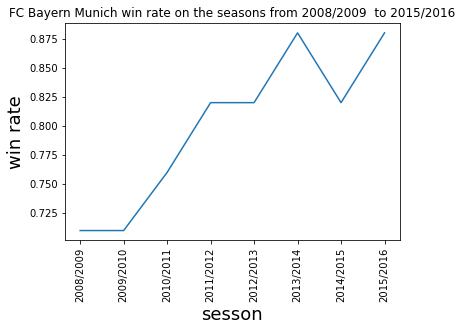

In [40]:
y =  top_impoved_teams.iloc[0,1:-1]
x = seasons
plt.plot(x,y)
plt.xlabel('sesson',fontsize=18)
plt.ylabel('win rate',fontsize=18)
plt.title('FC Bayern Munich win rate on the seasons from 2008/2009  to 2015/2016')
plt.xticks(rotation = 90)
plt.show()

### now let's see the top 10 teams that get worse during the time period

In [41]:
top_worsen_teams = df_team.sort_values(by= 'improve coefficient' ).head(10).round(2)
top_worsen_teams

,name,win rate_2008/2009,win rate_2009/2010,win rate_2010/2011,win rate_2011/2012,win rate_2012/2013,win rate_2013/2014,win rate_2014/2015,win rate_2015/2016,improve coefficient
id,,,,,,,,,,
9783,RC Deportivo de La Coruña,0.53,0.47,0.42,0.32,0.32,0.26,0.26,0.21,-0.97
9879,Fulham,0.58,0.58,0.42,0.53,0.37,0.26,0.26,0.26,-0.92
10211,SC Beira Mar,0.33,0.33,0.33,0.27,0.20,0.20,0.20,0.20,-0.91
7730,FC Lausanne-Sports,0.41,0.41,0.41,0.41,0.33,0.17,0.17,0.17,-0.90
9777,Servette FC,0.41,0.41,0.41,0.41,0.22,0.22,0.22,0.22,-0.87
8548,Rangers,0.79,0.79,0.74,0.63,0.63,0.63,0.63,0.63,-0.87
8528,Wigan Athletic,0.42,0.32,0.26,0.26,0.21,0.21,0.21,0.21,-0.87
8540,Palermo,0.74,0.68,0.58,0.53,0.26,0.42,0.42,0.32,-0.86
8564,Milan,0.74,0.63,0.68,0.59,0.68,0.58,0.47,0.47,-0.86


### it seems that RC Deportivo de La Coruña	is the most imporved team during the time period with -0.97

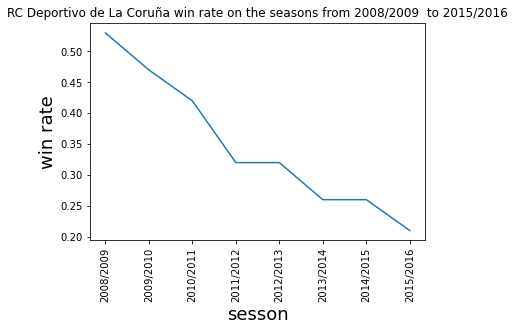

In [42]:
y =  top_worsen_teams.iloc[0,1:-1]
x = seasons
plt.plot(x,y)
plt.ylabel('win rate',fontsize=18)
plt.xlabel('sesson',fontsize=18)
plt.title('RC Deportivo de La Coruña win rate on the seasons from 2008/2009  to 2015/2016')
plt.xticks(rotation = 90)
plt.show()

In [43]:
avergae_win_rate=df_team['name'].copy()
avergae_win_rate = pd.DataFrame(avergae_win_rate)
averge= pd.DataFrame(df_team.iloc[:,1:-1].mean(axis = 1))
avergae_win_rate['total averge win rate']=averge


# which teams have the highest win rate during that time period?

### first lest create a separate dataframe that contains the total averge win rate for each team

In [44]:
avergae_win_rate=df_team['name'].copy()
avergae_win_rate = pd.DataFrame(avergae_win_rate)
averge= pd.DataFrame(df_team.iloc[:,1:-1].mean(axis = 1))
avergae_win_rate['total averge win rate']=averge


In [45]:
avergae_win_rate.sort_values(by= 'total averge win rate', ascending = False)

,name,total averge win rate
id,,
8634,FC Barcelona,0.861842
8633,Real Madrid CF,0.848684
9773,FC Porto,0.823529
9772,SL Benfica,0.820588
9823,FC Bayern Munich,0.801471
...,...,...
9912,DSC Arminia Bielefeld,0.117647
8244,Widzew Łódź,0.108333
108893,AC Arles-Avignon,0.105263


#### we can find now that FC Barcelona	have the highest  win rate  and Real Madrid CF comes next 
#### and the last we have Dunfermline Athletic	with averge win rate of 0.05

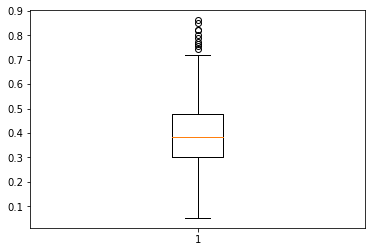

In [46]:
plt.boxplot(avergae_win_rate['total averge win rate']);


#### it seems that most of teams has a win rate between 0.3 and 0.5 

# Who are the oldest, tallest, shortest & heaviest players that were playing at that period?

In [47]:
df_player.describe()

,height,weight,age
count,11060.000000,11060.000000,11060.000000
mean,181.867445,168.380289,35.357143
std,6.369201,14.990217,5.481362
min,157.480000,117.000000,23.000000
25%,177.800000,159.000000,31.000000
50%,182.880000,168.000000,35.000000
75%,185.420000,179.000000,39.000000
max,208.280000,243.000000,55.000000


#### we can some information about  height and weight and age of the players and it's found that all are normally distributed

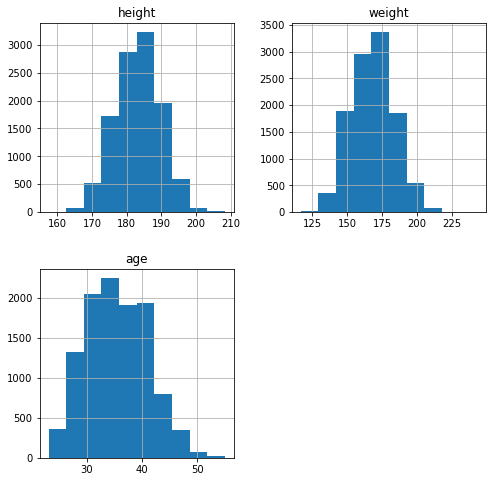

In [48]:
df_player.hist(figsize = (8,8));

In [49]:
df_player[df_player['age']==df_player['age'].max()]

,name,height,weight,age
id,,,,
39425,Alberto Fontana,185.42,161,55


In [50]:
df_player[df_player['weight']==df_player['weight'].max()]

,name,height,weight,age
id,,,,
148325,Kristof van Hout,208.28,243,35
27313,Tim Wiese,193.04,243,41


In [51]:
df_player[df_player['height']==df_player['height'].max()]

,name,height,weight,age
id,,,,
148325,Kristof van Hout,208.28,243,35


In [52]:
df_player[df_player['height']==df_player['height'].min()]

,name,height,weight,age
id,,,,
97226,Juan Quero,157.48,117,38


# what is the facotrs that affect the player rating

In [53]:
df_player_att

,id,rating,foot,finishing,free_kick,sprint,shot_power,jumping,penalties
0,505942,67.0,right,44.0,39.0,64.0,55.0,58.0,48.0
1,505942,67.0,right,44.0,39.0,64.0,55.0,58.0,48.0
2,505942,62.0,right,44.0,39.0,64.0,55.0,58.0,48.0
3,505942,61.0,right,43.0,38.0,64.0,54.0,58.0,47.0
4,505942,61.0,right,43.0,38.0,64.0,54.0,58.0,47.0
...,...,...,...,...,...,...,...,...,...
183973,39902,83.0,right,77.0,78.0,72.0,76.0,58.0,83.0
183974,39902,78.0,right,76.0,74.0,67.0,75.0,58.0,70.0
183975,39902,77.0,right,71.0,74.0,67.0,75.0,58.0,70.0
183976,39902,78.0,right,64.0,73.0,60.0,72.0,58.0,53.0


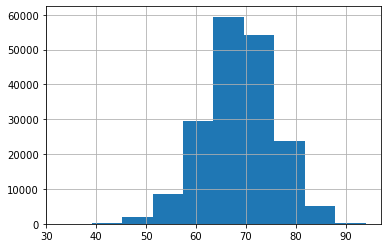

In [54]:
df_player_att['rating'].hist();

### now we can see that most players rating are in betwen 65 and 75 and it's normally distributed

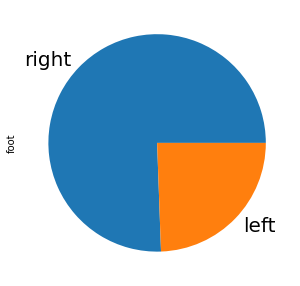

In [73]:
df_player_att['foot'].value_counts().plot(kind='pie', figsize=(5, 5),fontsize='20');


#### we  can find now the most players prefer playing with the right foot

In [56]:
df_player_att.describe()

,id,rating,finishing,free_kick,sprint,shot_power,jumping,penalties
count,183142.000000,183142.000000,183142.000000,183142.000000,183142.000000,183142.000000,183142.000000,183142.000000
mean,136294.314139,68.600015,49.921078,49.380950,68.051244,61.808427,66.969045,55.003986
std,137080.717171,7.041139,19.038705,17.831746,12.569721,16.135143,10.950185,15.546519
min,2625.000000,33.000000,1.000000,1.000000,12.000000,2.000000,14.000000,2.000000
25%,34952.000000,64.000000,34.000000,36.000000,62.000000,54.000000,60.000000,45.000000
50%,78411.000000,69.000000,53.000000,50.000000,69.000000,65.000000,68.000000,57.000000
75%,191616.000000,73.000000,65.000000,63.000000,77.000000,73.000000,74.000000,67.000000
max,750584.000000,94.000000,97.000000,97.000000,97.000000,97.000000,96.000000,96.000000


In [57]:
df_player_att.corr()

,id,rating,finishing,free_kick,sprint,shot_power,jumping,penalties
id,1.000000,-0.322389,-0.060387,-0.150856,0.095866,-0.123198,-0.140637,-0.164783
rating,-0.322389,1.000000,0.329298,0.349592,0.254841,0.427996,0.257279,0.393189
finishing,-0.060387,0.329298,1.000000,0.632248,0.509506,0.726982,0.008911,0.720388
free_kick,-0.150856,0.349592,0.632248,1.000000,0.394848,0.682790,-0.033079,0.665831
sprint,0.095866,0.254841,0.509506,0.394848,1.000000,0.486560,0.176021,0.409496
shot_power,-0.123198,0.427996,0.726982,0.682790,0.486560,1.000000,0.098940,0.675964
jumping,-0.140637,0.257279,0.008911,-0.033079,0.176021,0.098940,1.000000,0.057939
penalties,-0.164783,0.393189,0.720388,0.665831,0.409496,0.675964,0.057939,1.000000


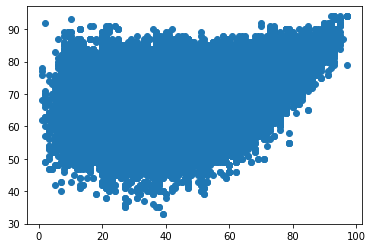

In [58]:
plt.scatter(x =df_player_att['finishing'],y =df_player_att['rating']);

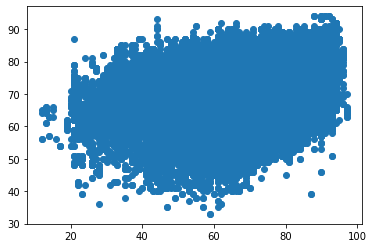

In [59]:
plt.scatter(x =df_player_att['sprint'],y =df_player_att['rating']);

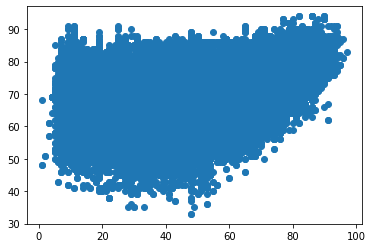

In [60]:
plt.scatter(x =df_player_att['free_kick'],y =df_player_att['rating']);

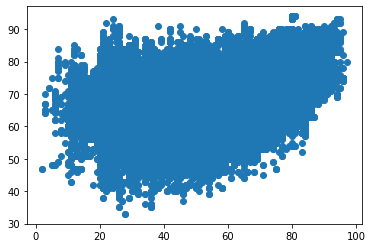

In [61]:
plt.scatter(x =df_player_att['shot_power'],y =df_player_att['rating']);

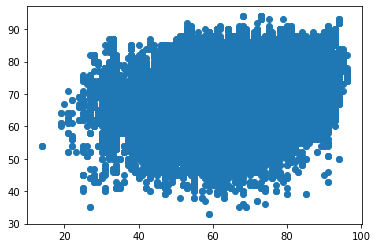

In [62]:
plt.scatter(x =df_player_att['jumping'],y =df_player_att['rating']);

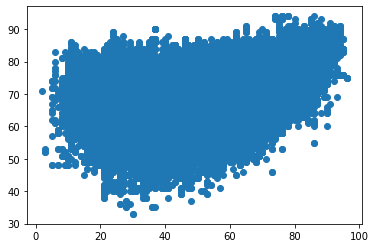

In [63]:
plt.scatter(x =df_player_att['penalties'],y =df_player_att['rating']);

### it seems that finishing,freekick and pepenalties is some how corrolated with the player rating

# who is the top rated player during that period

In [64]:
top_rated = df_player_att[df_player_att['rating'].max()==df_player_att['rating']]['id'].head(1)
top_rated

102482    30981
Name: id, dtype: int64

In [65]:
df_player.loc[top_rated.iloc[0]]

name      Lionel Messi
height          170.18
weight             159
age                 35
Name: 30981, dtype: object

### undobubtly he is Lionel Messi

# Which players had scored the most penalties

In [66]:
top_p = df_player_att[df_player_att['penalties'].max()==df_player_att['penalties']]['id'].head(1)
top_p

149591    39225
Name: id, dtype: int64

In [68]:
df_player.loc[top_p.iloc[0]]

name      Rickie Lambert
height            187.96
weight               170
age                   40
Name: 39225, dtype: object

#### finally Rickie Lambert had scored most of the penalties at that period

<a id='conclusions'></a>
## Conclusions



### finally we reach some findings  such that FC Barcelona	 has the highet win rate and maybe because we find that the top rated player in that period was Lionel Messi who was playing for FC Barcelona at that time. Then we also find that FC Bayern Munich has really imporved from the 2008/009 to 2015/2016 and we saw how it's win rate has been really increased throw that period. After that we took a look at the some statistics like the oldes player, tallest one and so on . Finally we saw how some player attributes can affect the players rating 